In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df =pd.read_csv('placement.csv')

In [ ]:
df


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df.shape

(100, 4)

# Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model






     

In [ ]:
df =df.iloc[: ,1: ]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
import matplotlib.pyplot as plt


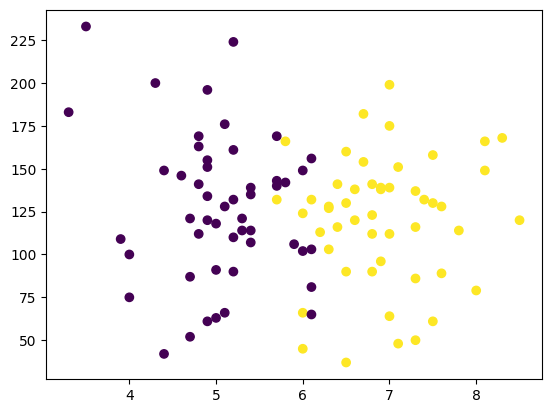

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])


In [ ]:
x=df.iloc[:, 0:2]
y=df.iloc[: ,-1]

In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
y.shape

(100,)

In [ ]:
x = df[['cgpa','iq']]
y = df['placement']

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)


In [ ]:
x_train

,cgpa,iq
84,5.7,169.0
60,6.9,139.0
7,5.0,63.0
69,8.5,120.0
4,5.8,142.0
...,...,...
96,4.4,42.0
40,4.9,134.0
91,7.5,158.0
64,7.0,64.0


In [ ]:
y_train

,placement
84,0
60,1
7,0
69,1
4,0
...,...
96,0
40,0
91,1
64,1


In [ ]:
x_test

,cgpa,iq
29,7.0,112.0
1,5.9,106.0
78,6.1,81.0
14,6.1,103.0
98,6.3,103.0
27,6.0,124.0
72,7.3,116.0
45,6.0,66.0
23,4.7,87.0
2,5.3,121.0


In [ ]:
y_test

,placement
29,1
1,0
78,0
14,0
98,1
27,1
72,1
45,1
23,0
2,0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train)

In [ ]:
x_train

array([[-0.2399813 ,  1.05490746],
       [ 0.78041163,  0.31911564],
       [-0.83521051, -1.54489031],
       [ 2.14093554, -0.14688585],
       [-0.15494856,  0.39269482],
       [-1.09030875, -1.81468065],
       [ 0.01511693,  0.56437958],
       [-0.66514502,  2.40385914],
       [ 0.27021517,  0.0493253 ],
       [-0.58011228, -0.29404421],
       [-1.34540698,  0.56437958],
       [-1.43043972,  1.81522568],
       [-0.49507953,  0.31911564],
       [-1.005276  , -0.343097  ],
       [ 1.20557535,  0.14743088],
       [ 0.86544438,  1.20206583],
       [ 0.35524791, -0.24499143],
       [-1.005276  ,  0.36816843],
       [ 1.37564084, -0.90720407],
       [ 0.10014968,  0.14743088],
       [ 0.18518242, -0.31857061],
       [ 0.44028065,  0.09837809],
       [-0.66514502, -0.88267767],
       [ 1.37564084,  0.0493253 ],
       [ 0.44028065,  0.83416991],
       [-1.68553796, -1.25057358],
       [-0.92024326, -1.5939431 ],
       [-0.49507953,  0.22101006],
       [ 0.10014968,

In [ ]:
x_test = scaler.transform(x_test)

In [ ]:
x_test

array([[ 0.86544438, -0.343097  ],
       [-0.06991581, -0.49025537],
       [ 0.10014968, -1.10341522],
       [ 0.10014968, -0.56383455],
       [ 0.27021517, -0.56383455],
       [ 0.01511693, -0.04878027],
       [ 1.12054261, -0.24499143],
       [ 0.01511693, -1.47131113],
       [-1.09030875, -0.95625685],
       [-0.58011228, -0.12235946]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
clf.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred =clf.predict(x_test)

In [ ]:
y_test

,placement
29,1
1,0
78,0
14,0
98,1
27,1
72,1
45,1
23,0
2,0


In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
accuracy_score(y_test,y_pred)

0.8

In [ ]:
from mlxtend.plotting import plot_decision_regions


<Axes: >

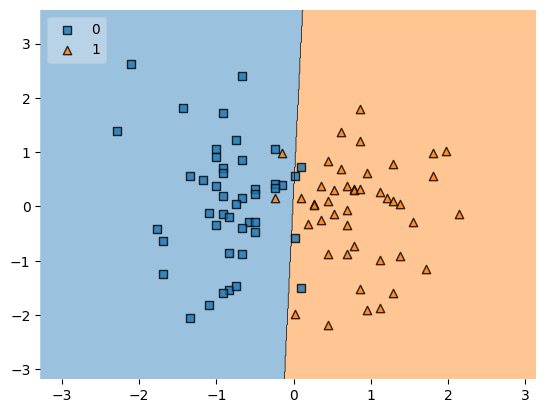

In [ ]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)


In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))